# Header

In [1]:
import importlib
import xarray_sf_funcs as xsfuncs
from dask.distributed import Client
import dask
import os
import re
import glob
import warnings
import logging
import xarray as xr
import numpy as np
import finufft
import matplotlib.pyplot as plt

# Reload the xsfuncs module
importlib.reload(xsfuncs)

warnings.filterwarnings("ignore")


In [2]:

# # Create a Dask client

# # Disable spilling to disk by setting high memory target and spill thresholds
# dask.config.set({
#     'temporary_directory': '/Volumes/Promise Disk/tmp'
# })

# client = Client(n_workers=8, threads_per_worker=1, memory_limit='48GB')
# client

In [3]:
region_dict = {
    'acc': {'lat_north': -53, 'lat_south': -57.5, 'lon_east': 158, 'lon_west': 148, 'reduce_xd_num': 1},
    'nwpacific': {'lat_north': 23, 'lat_south': 19, 'lon_east': 137, 'lon_west': 132, 'reduce_xd_num': 1},
    'capebasin': {'lat_north': -41.01421, 'lat_south': -44.99279, 'lon_east': 16, 'lon_west': 11, 'reduce_xd_num': 1},
    'newcaledonia': {'lat_north': -22, 'lat_south': -26, 'lon_east': 171, 'lon_west': 166, 'reduce_xd_num': 1},
    'nwaustralia': {'lat_north': -11, 'lat_south': -15, 'lon_east': 125, 'lon_west': 120, 'reduce_xd_num': 1},
    'westatlantic': {'lat_north': 38.7, 'lat_south': 32.7, 'lon_east': -73, 'lon_west': -76, 'reduce_xd_num': 1},
    'labradorsea': {'lat_north': 63.79824, 'lat_south': 59.5549, 'lon_east': -58.52856, 'lon_west': -63.61784, 'reduce_xd_num': 1},
    'Florida': {'lat_north': 29, 'lat_south': 24, 'lon_east': -77, 'lon_west': -82, 'reduce_xd_num': 1},
    'GrandBanks': {'lat_north': 40, 'lat_south': 35, 'lon_east': -45, 'lon_west': -50, 'reduce_xd_num': 1},
    'Arbic': {'lat_north': 43, 'lat_south': 27.5, 'lon_east': -40, 'lon_west': -60, 'reduce_xd_num': 1},
    'Equator': {'lat_north': 5, 'lat_south': -5, 'lon_east': -10, 'lon_west': -35, 'reduce_xd_num': 1},
    'Interior': {'lat_north': 32, 'lat_south': 22, 'lon_east': -30, 'lon_west': -42, 'reduce_xd_num': 1},
    'GulfStream': {
        'southwest': (-80, 25),  # Bottom-left corner
        'southeast': (-35, 25),  # Bottom-right corner
        'northwest': (-80, 39),  # Top-left corner
        'northeast': (-35, 49),  # Top-right corner
        'reduce_xd_num': 1}
}

# LLC4320 Four Regions

In [ ]:
import logging
import re
import glob
import os
from distributed import Client

# Set up Dask client
client = Client(n_workers=4, threads_per_worker=1, memory_limit='96GB')
client

# Custom logging handler to capture Dask warnings
class DaskWarningHandler(logging.Handler):
    def emit(self, record):
        if "distributed.worker.memory" in record.name and "WARNING" in record.levelname:
            if "Unmanaged memory use is high" in record.msg or "Worker is at" in record.msg:
                raise RuntimeError(f"Dask warning encountered: {record.msg}")

# Add the custom handler to the root logger
logger = logging.getLogger()
handler = DaskWarningHandler()
logger.addHandler(handler)

region_skips = [
    'Florida',  'unavailable',
    'GrandBanks',  'unavailable',
    'Arbic',  'unavailable',
    'Equator',  'unavailable',
    'Interior',  'unavailable',
    'GulfStream',  'unavailable'
]

dates = [f"2011{str(month).zfill(2)}{str(day).zfill(2)}" for month in [11, 12] for day in range(1, 32)]
dates = [date for date in dates if (date >= "20111113") and (date <= "20111213")]
# Remove November 31st
dates.remove("20111131")
keep_analysis_dates = []#['20250918', '20250922', '20250923']  # Filenames that begin with any of these dates will be kept and those dates/regions will be skipped

for date in dates:
    print(f"Processing date: {date}")

    for region, params in region_dict.items():

        # Skip regions that have already been processed
        if region in region_skips:
            print(f"Skipping region: {region}, {region_skips[region_skips.index(region) + 1]}")
            continue

        # Check if file exists for date, region, and analysis date, using * wildcard 
        # for the analysis date because I only want to check the date, not the time
        skip_region = False
        for keep_analysis_date in keep_analysis_dates:
            file_pattern = f"data/MITgcm/{region}/{keep_analysis_date}*{region}*{date}*.nc"
            matching_files = glob.glob(file_pattern)
            if matching_files:
                print(f"Skipping region: {region}, already processed for date {date} with analysis date {keep_analysis_date}: {matching_files}")
                skip_region = True
                break
            else:
                skip_region = False

        if skip_region:
            skip_region = False
            continue            

        reduce_xd_num = params['reduce_xd_num']

        parent_dir = f"/Volumes/Promise Disk/data/mitgcm/{region}_data"

        file_names = glob.glob(f"{parent_dir}/*.nc")
        file_names = [os.path.basename(fn) for fn in file_names]
        date_pattern = re.compile(r'\d{8}')  # Matches dates in the format YYYYMMDD
        dates = sorted([date_pattern.search(fn).group() for fn in file_names if date_pattern.search(fn)])

        print(f"Processing region: {region} with reduce_xd_num: {reduce_xd_num}")
        
        # Call the function to compute and save simulations
        xsfuncs.compute_and_save_llc4320(
            region_name=region,
            date=date,
            coarsen=3,  # Coarsen by a factor of 3, results in 1/14 degree resolution
            CG=True,
            reduce_xd_num=reduce_xd_num,
            scalar='q'
        )

/Users/cassswagner/miniconda3/envs/venv-swotP1/lib/python3.14/site-packages/distributed/node.py:182: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 55665 instead
  warnings.warn(


# SimSWOT 8 Regions

In [ ]:
region_skips = [
    # 'acc',  'already processed',
    # 'npc',  'already processed',
    # 'capebasin',  'already processed',
    # 'nwaustralia',  'already processed',
    # 'westatlantic',  'already processed',
    # 'Florida',  'already processed',
    # 'GrandBanks',  'mostly processed, some files missing',
    'Arbic',  'too big',
    'Equator',  'too big',
    'Interior',  'too big',
    'GulfStream',  'unsure how to process, needs special handling'
]

parent_dir = "/Volumes/Promise Disk/data/simulated_swot/full_data"

file_names = glob.glob(f"{parent_dir}/*.nc")
file_names = [os.path.basename(fn) for fn in file_names]
cycle_nums = sorted(set(
    re.search(r"Expert_(\d+)", fn).group(1).zfill(3) for fn in file_names if re.search(r"Expert_(\d+)", fn)
))
print(f"Found cycle numbers: {cycle_nums}")

for cycle_num in cycle_nums:

    for region, params in region_dict.items():

        # Skip regions that have already been processed
        if region in region_skips:
            print(f"Skipping region: {region}, {region_skips[region_skips.index(region) + 1]}")
            continue

        # Check for existing files if run_new is False
        region_output_dir = os.path.join('data/simSWOT', region)
        if not os.path.exists(region_output_dir):
            os.makedirs(region_output_dir)

        reduce_xd_num = params['reduce_xd_num']
        lat_north = params['lat_north']
        lat_south = params['lat_south']
        lon_east = params['lon_east']
        lon_west = params['lon_west']

        # if longitude is negative, convert to 0-360 range
        if lon_west < 0:
            lon_west += 360
        if lon_east < 0:
            lon_east += 360

        print(f"Processing region: {region} with reduce_xd_num: {reduce_xd_num}")
        
        # Call the function to compute and save simulations

        retries = 0
        max_retries = 3
        while retries < max_retries:
            try:
                print(f"Processing cycle number: {cycle_num}")
                # Call the function to compute and save simulations
                xsfuncs.compute_and_save_simswot(
                    region_name=region, 
                    cycle_num=cycle_num,
                    lat_north=lat_north,
                    lat_south=lat_south,
                    lon_east=lon_east,
                    lon_west=lon_west,
                    CG=True,
                    cleaned=True,
                    reduce_xd_num=reduce_xd_num,
                    scalar='q'
                )
                break  # Exit loop if successful
            except Exception as e:
                print(f"Error processing cycle {cycle_num} for region {region}: {e}")
                retries += 1
                if retries >= max_retries:
                    print(f"Max retries reached for cycle {cycle_num} in region {region}. Skipping.")
                else:
                    print(f"Retrying cycle {cycle_num} in region {region} ({retries}/{max_retries})...")
                    # Optionally, you could add a delay here before retrying
                    # time.sleep(5)  # Uncomment if you want to wait before retrying


# SWOT L3 8 Regions

*THE ONLY COMPLETE SCIENCE PHASE CYCLES ARE 001-027*

In [ ]:
region_skips = [
    # 'acc',  'already processed',
    'npc',  'already processed',
    'capebasin',  'already processed',
    'nwaustralia',  'already processed',
    'westatlantic',  'already processed',
    'Florida',  'already processed',
    'GrandBanks',  'processed through cycle 26',
    'Arbic',  'too big',
    'Equator',  'too big',
    'Interior',  'troublesome',
    'GulfStream',  'unsure how to process, needs special handling'
]


# Define the parent directory containing the cycle directories
parent_dir = "/Volumes/Promise Disk/data/validated_swot/SWOT_L3_LR_SSH/SWOT_L3_LR_SSH_2.0/Expert"

# Define the output directory for processed data
output_dir = "data/SWOT_L3"

# List all directories in the parent directory
all_dirs = [d for d in os.listdir(parent_dir) if os.path.isdir(os.path.join(parent_dir, d))]

# Extract numeric suffixes from directory names and format them as zero-padded strings
cycle_nums = sorted(
    re.search(r"cycle_(\d+)", d).group(1).zfill(3) for d in all_dirs if re.search(r"cycle_(\d+)", d)
)

# Drop all cycle numbers that are not in the range 001 to 100
cycle_nums = [num for num in cycle_nums if 1 <= int(num) <= 100]

# Drop specific cycle numbers that are known to be problematic for Interior region
problematic_cycles = {'002', '003', '005'}
# cycle_nums = [num for num in cycle_nums if num not in problematic_cycles]

# Start from cycle #
# cycle_nums = [num for num in cycle_nums if int(num) >= 7]

print(f"Cycle numbers: {cycle_nums}")


run_new = True # Set to True if you want to run all cycles/regions again, otherwise skips files that already exist

for cycnum in cycle_nums:

    for region, params in region_dict.items():

        # Skip regions that have already been processed
        if region in region_skips:
            print(f"Skipping region: {region}, {region_skips[region_skips.index(region) + 1]}")
            continue

        if region == 'Interior' and cycnum in problematic_cycles:
            print(f"Skipping cycle {cycnum} for region {region} due to known issues.")
            continue

        reduce_xd_num = params['reduce_xd_num']
        lat_north = params['lat_north']
        lat_south = params['lat_south']
        lon_east = params['lon_east']
        lon_west = params['lon_west']

        # if longitude is negative, convert to 0-360 range
        if lon_west < 0:
            lon_west += 360
        if lon_east < 0:
            lon_east += 360

        print(f"Processing region: {region} with reduce_xd_num: {reduce_xd_num}")
        
        # Check for existing files if run_new is False
        region_output_dir = os.path.join(output_dir, region)
        if not os.path.exists(region_output_dir):
            os.makedirs(region_output_dir)

        # Skip cycles if the corresponding file already exists and run_new is False
        if not run_new:
            # Print all files in the region output directory
            file_names = os.listdir(region_output_dir)
            existing_files = [
                f for f in os.listdir(region_output_dir)
                if re.search(rf"cycle_{cycnum}(?:\b|[^a-zA-Z0-9])", f)  # Match cycle_<cycnum> in the file name
            ]
            if existing_files:
                print(f"Skipping cycle {cycnum} for region {region} as output file already exists: {existing_files[0]}")
                continue

        retries = 0
        max_retries = 3
        while retries < max_retries:
            try:
                print(f"Processing cycle {cycnum} for region {region} (Attempt {retries + 1}/{max_retries})")
                
                # Catch warnings as exceptions
                with warnings.catch_warnings(record=True) as caught_warnings:
                    warnings.simplefilter("always")  # Catch all warnings
                    xsfuncs.compute_and_save_SWOT_L3(
                        region_name=region,
                        cycle_num=cycnum,
                        lat_north=lat_north,
                        lat_south=lat_south,
                        lon_east=lon_east,
                        lon_west=lon_west,
                        CG=True,
                        LLL=True,
                        scalar='q',
                        reduce_xd_num=reduce_xd_num,
                    )
                    
                    # Check if the specific warning occurred
                    for w in caught_warnings:
                        if "Unmanaged memory use is high" in str(w.message):
                            print(f"Warning encountered: {w.message}. Skipping cycle {cycnum} for region {region}.")
                            raise RuntimeError("Memory warning")

                # If successful, break out of the retry loop
                break

            except RuntimeError as e:
                retries += 1
                print(f"RuntimeError encountered for region {region}, cycle {cycnum}: {e}")
                if retries >= max_retries:
                    print(f"Skipping cycle {cycnum} for region {region} after {max_retries} retries.")
                    # Log which cycle and region were skipped
                    with open("skipped_cycles.log", "a") as log_file:
                        log_file.write(f"Skipped cycle {cycnum} for region {region} after {max_retries} retries.\n")
                else:
                    print(f"Retrying cycle {cycnum} for region {region} (Attempt {retries + 1}/{max_retries})")

            except Exception as e:
                retries += 1
                print(f"Error encountered for region {region}, cycle {cycnum}: {e}")
                if retries >= max_retries:
                    print(f"Skipping cycle {cycnum} for region {region} after {max_retries} retries.")
                    # Log which cycle and region were skipped
                    with open("skipped_cycles.log", "a") as log_file:
                        log_file.write(f"Skipped cycle {cycnum} for region {region} after {max_retries} retries. Error details: {e}\n")
                else:
                    print(f"Retrying cycle {cycnum} for region {region} (Attempt {retries + 1}/{max_retries})")

### Snapshots

In [ ]:
region_skips = [
    'acc',  'already processed',
    'npc',  'already processed',
    'capebasin',  'already processed',
    'nwaustralia',  'already processed',
    'westatlantic',  'already processed',
    # 'Florida',  'unavailable',
    # 'GrandBanks',  'unavailable',
    # 'Arbic',  'unavailable',
    # 'Equator',  'unavailable',
    # 'Interior',  'unavailable',
    'GulfStream',  'unsure how to process, needs special handling'
]


# Define the parent directory containing the cycle directories
parent_dir = "/Volumes/Promise Disk/data/validated_swot/SWOT_L3_LR_SSH/SWOT_L3_LR_SSH_2.0/Expert"

# Define the output directory for processed data
output_dir = "data/SWOT_L3"

# List all directories in the parent directory
all_dirs = [d for d in os.listdir(parent_dir) if os.path.isdir(os.path.join(parent_dir, d))]

# Extract numeric suffixes from directory names and format them as zero-padded strings
cycle_nums = sorted(
    re.search(r"cycle_(\d+)", d).group(1).zfill(3) for d in all_dirs if re.search(r"cycle_(\d+)", d)
)

print(f"Cycle numbers: {cycle_nums}")

# drop all cycles outside of 001-027
cycle_nums = [num for num in cycle_nums if int(num) >= 1 and int(num) <= 27]

run_new = True # Set to True if you want to run all cycles/regions again, otherwise skips files that already exist
for region, params in region_dict.items():

    # Skip regions that have already been processed
    if region in region_skips:
        print(f"Skipping region: {region}, {region_skips[region_skips.index(region) + 1]}")
        continue

    reduce_xd_num = params['reduce_xd_num']
    lat_north = params['lat_north']
    lat_south = params['lat_south']
    lon_east = params['lon_east']
    lon_west = params['lon_west']

    # if longitude is negative, convert to 0-360 range
    if lon_west < 0:
        lon_west += 360
    if lon_east < 0:
        lon_east += 360

    print(f"Processing region: {region} with reduce_xd_num: {reduce_xd_num}")
    
    # Check for existing files if run_new is False
    region_output_dir = os.path.join(output_dir, region)
    if not os.path.exists(region_output_dir):
        os.makedirs(region_output_dir)

    # Call the function to compute and save simulations
    for cycnum in cycle_nums[:1]:
        # Skip cycles if the corresponding file already exists and run_new is False
        if not run_new:
            # Print all files in the region output directory
            file_names = os.listdir(region_output_dir)
            existing_files = [
                f for f in os.listdir(region_output_dir)
                if re.search(rf"cycle_{cycnum}(?:\b|[^a-zA-Z0-9])", f)  # Match cycle_<cycnum> in the file name
            ]
            if existing_files:
                print(f"Skipping cycle {cycnum} for region {region} as output file already exists: {existing_files[0]}")
                continue

        print(f"Processing cycle {cycnum} for region {region}")
        xsfuncs.generate_snapshots_SWOT_L3(
            region_name=region,
            cycle_num=cycnum,  # Adjust cycle number as needed 
            lat_north=lat_north,
            lat_south=lat_south,
            lon_east=lon_east,
            lon_west=lon_west,
        )

# NEMO 8 Regions

In [ ]:

# Create a Dask client for NEMO processing
client = Client(n_workers=32, threads_per_worker=1, memory_limit='12GB')
client

region_skips = [
    'acc',  'already processed',
    'npc',  'already processed',
    'capebasin',  'already processed',
    'nwaustralia',  'already processed',
    'westatlantic',  'already processed',
    'Florida',  'already processed',
    'GrandBanks',  'already processed',
    'Arbic',  'too big',
    'Equator',  'too big',
    # 'Interior',  'already processed',
    'GulfStream',  'unsure how to process, needs special handling'
]


for region, params in region_dict.items():

    # Skip regions that have already been processed
    if region in region_skips:
        print(f"Skipping region: {region}, {region_skips[region_skips.index(region) + 1]}")
        continue

    reduce_xd_num = params['reduce_xd_num']
    lat_north = params['lat_north']
    lat_south = params['lat_south']
    lon_east = params['lon_east']
    lon_west = params['lon_west']

    # # if longitude is negative, convert to 0-360 range
    # if lon_west < 0:
    #     lon_west += 360
    # if lon_east < 0:
    #     lon_east += 360

    print(f"Processing region: {region} with reduce_xd_num: {reduce_xd_num}")
    
    output_dir = "data/NEMO"
    region_output_dir = os.path.join(output_dir, region)
    if not os.path.exists(region_output_dir):
        os.makedirs(region_output_dir)

    # Call the function to compute and save simulations
    xsfuncs.compute_and_save_NEMO(
        filename="NEMO_2011-2012",
        inputpath="/Volumes/Promise Disk/data/NEMO/2011-2012_data/cmems_mod_glo_phy_my_0.083deg_P1D-m_uo-vo_180.00W-179.92E_80.00S-90.00N_0.49m_2011-09-13-2012-11-15.nc",
        region_name=region,
        lat_north=lat_north,
        lat_south=lat_south,
        lon_east=lon_east,
        lon_west=lon_west,
        CG=True,
        reduce_xd_num=reduce_xd_num,
        scalar='q'
    )
        

### Snapshots

In [ ]:
region_skips = [
    # 'acc',  'already processed',
    # 'npc',  'already processed',
    # 'capebasin',  'already processed',
    # 'nwaustralia',  'already processed',
    # 'westatlantic',  'already processed'
]


for region, params in region_dict.items():

    # Skip regions that have already been processed
    if region in region_skips:
        print(f"Skipping region: {region}, {region_skips[region_skips.index(region) + 1]}")
        continue

    reduce_xd_num = params['reduce_xd_num']
    lat_north = params['lat_north']
    lat_south = params['lat_south']
    lon_east = params['lon_east']
    lon_west = params['lon_west']

    # # if longitude is negative, convert to 0-360 range
    # if lon_west < 0:
    #     lon_west += 360
    # if lon_east < 0:
    #     lon_east += 360

    print(f"Processing region: {region} with reduce_xd_num: {reduce_xd_num}")
    
    # Call the function to compute and save simulations
    xsfuncs.generate_snapshots_NEMO(
        region_name=region,
        lat_north=lat_north,
        lat_south=lat_south,
        lon_east=lon_east,
        lon_west=lon_west,
    )
        

# LLC4320 ACC compare with Wang et al. 2025

In [ ]:
import logging
import re
import glob
import os
from distributed import Client
import gc

# Configure Dask memory settings
dask.config.set({
    'distributed.worker.memory.target': 0.7,
    'distributed.worker.memory.spill': 0.8,
    'distributed.worker.memory.pause': 0.85,
    'distributed.worker.memory.terminate': 0.95
})

def create_client():
    """Helper function to create a new Dask client"""
    return Client(
        n_workers=16,
        threads_per_worker=1, 
        memory_limit='20GB',
    )

# Set up Dask client
client = create_client()

# Custom logging handler to capture Dask warnings
class DaskWarningHandler(logging.Handler):
    def emit(self, record):
        if "distributed.worker.memory" in record.name and "WARNING" in record.levelname:
            if "Unmanaged memory use is high" in record.msg or "Worker is at" in record.msg:
                raise RuntimeError(f"Dask warning encountered: {record.msg}")

# Add the custom handler to the root logger
logger = logging.getLogger()
handler = DaskWarningHandler()
logger.addHandler(handler)

# Set run_new flag
run_new = True

dates = [f"2012{str(month).zfill(2)}{str(day).zfill(2)}" for month in [3, 4, 5, 6, 7] for day in range(1, 32)]
dates = [date for date in dates if (date >= "20120329") and (date <= "20120710")]
dates.remove("20120431")
dates.remove("20120631")
print(dates)

# dates = [date for date in dates if date >= "20120606"]

output_dir = "data/MITgcm/acc/03292012-07102012_wang2025_range_acc_data"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

region = 'acc'
params = region_dict[region]

for idx, date in enumerate(dates):
    print(f"Processing date: {date}")
    
    # Restart client every 10 iterations
    if idx > 0 and idx % 10 == 0:
        print(f"Restarting Dask client after {idx} iterations...")
        client.close()
        gc.collect()
        client = create_client()
        print("Dask client restarted successfully")

    # Check for existing files if run_new is False
    if not run_new:
        existing_files = [
            f for f in os.listdir(output_dir)
            if re.search(rf"{date}(?:\b|[^a-zA-Z0-9])", f)
        ]
        if existing_files:
            print(f"Skipping date {date} for region {region} as output file already exists: {existing_files[0]}")
            continue

    reduce_xd_num = 1

    parent_dir = "/Volumes/Promise Disk/data/mitgcm/acc_data/03292012-07102012_wang2025_range_acc_data"
    child_dir = "03292012-07102012_wang2025_range_acc_data"

    print(f"Processing region: {region} with reduce_xd_num: {reduce_xd_num}")
    
    xsfuncs.compute_and_save_llc4320(
        region_name=region,
        child_dir=child_dir,
        date=date,
        coarsen=None,
        CG=True,
        reduce_xd_num=reduce_xd_num,
        scalar='q',
        Bessels=True,
        FFT=True,
        remove_timemean=True
    )
    client.run(gc.collect)

# Clean up at the end
client.close()

['20120329', '20120330', '20120331', '20120401', '20120402', '20120403', '20120404', '20120405', '20120406', '20120407', '20120408', '20120409', '20120410', '20120411', '20120412', '20120413', '20120414', '20120415', '20120416', '20120417', '20120418', '20120419', '20120420', '20120421', '20120422', '20120423', '20120424', '20120425', '20120426', '20120427', '20120428', '20120429', '20120430', '20120501', '20120502', '20120503', '20120504', '20120505', '20120506', '20120507', '20120508', '20120509', '20120510', '20120511', '20120512', '20120513', '20120514', '20120515', '20120516', '20120517', '20120518', '20120519', '20120520', '20120521', '20120522', '20120523', '20120524', '20120525', '20120526', '20120527', '20120528', '20120529', '20120530', '20120531', '20120601', '20120602', '20120603', '20120604', '20120605', '20120606', '20120607', '20120608', '20120609', '20120610', '20120611', '20120612', '20120613', '20120614', '20120615', '20120616', '20120617', '20120618', '20120619', '20

# LLC4320 any region with full date range

In [ ]:
import logging
import re
import glob
import os
from distributed import Client
import gc
import signal

# Configure Dask memory settings
dask.config.set({
    'distributed.worker.memory.target': 0.7,
    'distributed.worker.memory.spill': 0.8,
    'distributed.worker.memory.pause': 0.85,
    'distributed.worker.memory.terminate': 0.95,
    'logging.distributed': 'error'
})

def create_client():
    """Helper function to create a new Dask client"""
    return Client(
        n_workers=8,
        threads_per_worker=1, 
        memory_limit='48GB',
        silence_logs=logging.WARNING
    )

def reset_client(client):
    """Safely reset Dask client without crashing on teardown timeouts."""
    try:
        client.shutdown()
    except Exception as shutdown_err:
        print(f"Client shutdown warning (safe to ignore): {shutdown_err}")

    try:
        client.close()
    except Exception as close_err:
        print(f"Client close warning (safe to ignore): {close_err}")

    gc.collect()
    new_client = create_client()
    print("Created a fresh Dask client")
    return new_client

class RunTimeoutError(TimeoutError):
    pass

def _timeout_handler(signum, frame):
    raise RunTimeoutError("Run exceeded timeout window without completion")

# macOS supports SIGALRM (this notebook appears to run on macOS)
signal.signal(signal.SIGALRM, _timeout_handler)

# Set up Dask client
client = create_client()

# # Custom logging handler to capture Dask warnings
# class DaskWarningHandler(logging.Handler):
#     def emit(self, record):
#         if "distributed.worker.memory" in record.name and "WARNING" in record.levelname:
#             if "Unmanaged memory use is high" in record.msg or "Worker is at" in record.msg:
#                 raise RuntimeError(f"Dask warning encountered: {record.msg}")

# # Add the custom handler to the root logger
# logger = logging.getLogger()
# handler = DaskWarningHandler()
# logger.addHandler(handler)

# Set run_new flag
run_new = False

dates = [f"{str(year).zfill(4)}{str(month).zfill(2)}{str(day).zfill(2)}" for year in [2011, 2012] for month in range(1, 13) for day in range(1, 32)]
dates = [date for date in dates if (date <= "20121115") and (date >= "20110913")]

# Remove invalid dates
dates.remove("20110931")
dates.remove("20111131")
dates.remove("20120431")
dates.remove("20120631")

# Remove dates after cutoff, in case already processed
# dates = [date for date in dates if date >= "20120206"]

# region = 'labradorsea'
region_list = [
    'acc', 
    'nwpacific', 
    'capebasin', 
    'labradorsea', 
    'newcaledonia', 
    'nwaustralia', 
    'westatlantic',
    ]

output_dir = "data/MITgcm/2026-05-07"


ASF = True
LLL = True
CG = True
scalar = None
Bessels = True
timemean_removal_method = "snapshot_mean"  # options: None, "snapshot_mean"
taper_SF = True
coarsen = 5 # coarsen from 1/48 deg to 1/9.6 deg resolution


for idx, date in enumerate(dates):
    print(f"Processing date: {date}")

    for region in region_list:
        print(f"Processing region: {region}")

        output_dir = f"data/MITgcm/2026-05-07/{region}"
        if not os.path.exists(output_dir):
            os.makedirs(output_dir)

        params = region_dict[region]
        
        # Restart client every 10 iterations
        if idx > 0 and idx % 10 == 0:
            print(f"Restarting Dask client after {idx} iterations...")
            client = reset_client(client)
            gc.collect()
            print("Dask client restarted successfully")

        suffix = ""
        suffix += f"_{region}_{date}"
        suffix += f"_coarsen_to_1div{(48 / coarsen):.1f}deg"
        suffix += f"_timemean_removed_{timemean_removal_method}" if timemean_removal_method else ""
        suffix += f"{scalar}" if scalar else ""
        suffix += "_LLL" if LLL else ""
        suffix += "_Bessels" if Bessels else ""
        suffix += "_tapered" if taper_SF else ""
        suffix += "_CG" if CG else ""
        print(f"Output filename suffix: {suffix}")

        # Check for existing files if run_new is False
        if not run_new:
            existing_files = [
                f for f in os.listdir(output_dir)
                if suffix in f
                and re.search(rf"{date}(?:\b|[^a-zA-Z0-9])", f)
            ]
            if existing_files:
                print(f"Skipping date {date} for region {region} as output file already exists: {existing_files[0]}")
                continue

        reduce_xd_num = 1

        parent_dir = f"/Volumes/Promise Disk/data/mitgcm/{region}_data/{region}_all"
        child_dir = f"{region}_all"

        # print link to dask dashboard
        print(f"Dask dashboard link: {client.dashboard_link}")
        try:
            xsfuncs.compute_and_save_llc4320(
                region_name=region,
                date=date,
                outpath=output_dir,
                child_dir=child_dir,
                ASF=ASF,
                CG=CG,
                reduce_xd_num=reduce_xd_num,
                scalar=None,
                Bessels=Bessels,
                LLL=LLL,
                timemean_removal_method=timemean_removal_method,
                taper_SF=taper_SF,
                coarsen=coarsen
            )
            # client.run(gc.collect)

        except Exception as e:
            print(f"Failed for date {date} and region {region}: {e}")
            print("Skipping this date and region  retry failure. See logs for details.")
            with open("processing_errors.log", "a") as log_file:
                log_file.write(f"Failed to process date {date} for region {region}. Error details: {e}\n")

    # Clean up at the end
    client.close()

Processing date: 20110913
Processing region: acc
Output filename suffix: _acc_20110913_coarsen_to_1div9.6deg_timemean_removed_snapshot_mean_LLL_Bessels_tapered_CG
Skipping date 20110913 for region acc as output file already exists: 20260507_130740_LLC4320_acc_20110913_coarsen_to_1div9.6deg_timemean_removed_snapshot_mean_LLL_Bessels_tapered_CG.nc
Processing region: nwpacific
Output filename suffix: _nwpacific_20110913_coarsen_to_1div9.6deg_timemean_removed_snapshot_mean_LLL_Bessels_tapered_CG
Skipping date 20110913 for region nwpacific as output file already exists: 20260507_155346_LLC4320_nwpacific_20110913_coarsen_to_1div9.6deg_timemean_removed_snapshot_mean_LLL_Bessels_tapered_CG.nc
Processing region: capebasin
Output filename suffix: _capebasin_20110913_coarsen_to_1div9.6deg_timemean_removed_snapshot_mean_LLL_Bessels_tapered_CG
Skipping date 20110913 for region capebasin as output file already exists: 20260507_155614_LLC4320_capebasin_20110913_coarsen_to_1div9.6deg_timemean_removed_

# Testing

In [ ]:
import numpy as np

def get_gulfstream_coords():

    lat_min, lat_max = -90, 90  # Latitude range in degrees
    lon_min, lon_max = -180, 180  # Longitude range in degrees
    resolution = 1.0  # Grid resolution in degrees

    # Create 1D arrays for latitude and longitude
    latitudes = np.arange(lat_min, lat_max + resolution, resolution)
    longitudes = np.arange(lon_min, lon_max + resolution, resolution)

    # Create 2D latitude and longitude grids
    ULAT, ULONG = np.meshgrid(latitudes, longitudes, indexing='ij')

    # Constants
    radian = np.pi / 180  # Conversion factor from degrees to radians

    # Example ULAT and ULONG grids (replace with your actual data)
    # ULAT and ULONG should be 2D NumPy arrays
    # ULAT, ULONG = ...

    # Condition for the diagonal domain
    gulfstream_domain = (
        (np.abs(ULAT * radian - (0.4 * ULONG * radian + 62.0)) > 5.0) |
        (ULONG * radian > -35) |
        (ULONG * radian < -80)
    )

    # Apply the condition to create a mask
    gulfstream_mask = np.where(gulfstream_domain, 1, 0)

    # Extract the coordinates where the mask is 1
    gulfstream_coords = np.column_stack(np.where(gulfstream_mask == 1))
    gulfstream_coords = gulfstream_coords * resolution  # Convert indices to degrees
    gulfstream_coords = gulfstream_coords.astype(float)  # Ensure float type for coordinates

    # Convert to a dictionary with latitude and longitude
    gulfstream_dict = {
        'lat': gulfstream_coords[:, 0],
        'lon': gulfstream_coords[:, 1]
    }

    return gulfstream_dict, gulfstream_mask

In [ ]:
region_coordinates = {
    'Florida': {'lat_north': 29, 'lat_south': 24, 'lon_east': -77, 'lon_west': -82},
    'GrandBanks': {'lat_north': 40, 'lat_south': 35, 'lon_east': -45, 'lon_west': -50},
    'Arbic': {'lat_north': 43, 'lat_south': 27.5, 'lon_east': -40, 'lon_west': -60},
    'Equator': {'lat_north': 5, 'lat_south': -5, 'lon_east': -10, 'lon_west': -35},
    'Interior': {'lat_north': 32, 'lat_south': 22, 'lon_east': -30, 'lon_west': -42},
    'GulfStream': get_gulfstream_coords()
}

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.patches as mpatches

# Create a Plate Carrée projection
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})

# Add features to the map
ax.add_feature(cfeature.LAND, edgecolor='black', zorder=0)
ax.add_feature(cfeature.COASTLINE, zorder=1)
ax.set_extent([-82, 20, -10, 70], crs=ccrs.PlateCarree())  # Set map extent

# Define colors for each region
colors = ['tab:red', 'tab:blue', 'tab:green', 'tab:orange', 'tab:purple', 'tab:brown']

# Plot each region as a rectangle
for i, (region, coords) in enumerate(region_coordinates.items()):

    if region != 'GulfStream':

        lat_north = coords['lat_north']
        lat_south = coords['lat_south']
        lon_east = coords['lon_east']
        lon_west = coords['lon_west']
        
        # Plot the rectangle
        ax.add_patch(plt.Rectangle(
            (lon_west, lat_south),  # Bottom-left corner
            lon_east - lon_west,   # Width
            lat_north - lat_south, # Height
            facecolor='none', edgecolor=colors[i % len(colors)], linewidth=2,
            transform=ccrs.PlateCarree(), label=region
        ))

    else:
        # Plot the Gulf Stream region using the condition
        gulf_stream_coords = [
            (-80, 39),  # Top-left corner
            (-35, 49),  # Top-right corner
            (-35, 35),  # Bottom-right corner
            (-80, 25)   # Bottom-left corner
        ]

        # Add the diagonal rectangle for the Gulf Stream
        ax.add_patch(mpatches.Polygon(
            gulf_stream_coords,
            closed=True,
            edgecolor=colors[i % len(colors)],
            facecolor='none',
            linewidth=2,
            transform=ccrs.PlateCarree(),
            label=region
        ))

# Add a legend
ax.legend(loc='lower left')

# Add gridlines
ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')

# Show the plot
plt.title("Regions on Plate Carrée Projection")
plt.show()

In [ ]:
tmp_coords = get_gulfstream_coords()

In [ ]:
tmp_coords

### Test coarse graining

In [ ]:
import xarray as xr 
ds_SWOT_test = xr.open_dataset("/Volumes/Promise Disk/data/validated_swot/SWOT_L3_LR_SSH/SWOT_L3_LR_SSH_2.0/Expert/cycle_001/SWOT_L3_LR_SSH_Expert_001_153_20230726T155344_20230726T164510_v2.0.0.nc")

In [ ]:
filenames = glob.glob("/Volumes/Promise Disk/data/validated_swot/SWOT_L3_LR_SSH/SWOT_L3_LR_SSH_2.0/Expert/cycle_001/*.nc")

for fn in filenames:

    try:

        ds_SWOT_test = xr.open_dataset(fn)

        lat_north = region_dict['acc']['lat_north']
        lat_south = region_dict['acc']['lat_south']
        lon_east = region_dict['acc']['lon_east']
        lon_west = region_dict['acc']['lon_west']

        lat_indexer = ((ds_SWOT_test["latitude"] >= lat_south) &
                        (ds_SWOT_test["latitude"] <= lat_north)).compute()
        lon_indexer = ((ds_SWOT_test["longitude"] <= lon_east) &
                        (ds_SWOT_test["longitude"] >= lon_west)).compute()

        ds_SWOT_test = ds_SWOT_test.where(lat_indexer & lon_indexer, drop=True)

        break

    except ValueError as e:
        # print(f"Error processing file {fn}: {e}")
        pass
    

In [ ]:
ds_SWOT_test

In [ ]:
swot_dx = 2000
ds_calc = xsfuncs.calc_advection(ds_SWOT_test, qvar='CALC', uvar='ugos', vvar='vgos', xvar='num_pixels', yvar='num_lines', dx=swot_dx, dy=swot_dx)

ds_calc_computed = ds_calc.compute()

In [ ]:
from astropy.convolution import Tophat2DKernel
import numpy as np

sizes = np.logspace(0,2.5,5)

delayed_coarse_grain = dask.delayed(xsfuncs.coarse_grain)


ds_cg_list = [xsfuncs.coarse_grain(ds_calc_computed, filter='astropy', uvar='ugos', vvar='vgos', xvar='num_pixels', yvar='num_lines', qvar='q', dx=swot_dx, dy=swot_dx, kwargs={"kernel": Tophat2DKernel(s)}) for s in sizes for i in range(3)]

# ds_cg_list = [ds.persist() for ds in ds_cg_list]

In [ ]:
reshaped_ds_cg_list = np.asarray(ds_cg_list).reshape(
    len(sizes), 3, 2)

ds_cg_list_EFlux = [
    xr.DataArray(reshaped_ds_cg_list[i, :, 0], dims=["swath_num"])
    for i in range(len(sizes))
]
ds_cg_list_QFlux = [
    xr.DataArray(reshaped_ds_cg_list[i, :, 1], dims=["swath_num"])
    for i in range(len(sizes))
]

ds_cg_computed_EFlux = xr.concat(ds_cg_list_EFlux, dim="L")
ds_cg_computed_QFlux = xr.concat(ds_cg_list_QFlux, dim="L")
ds_cg_computed = xr.Dataset({
    "EFlux_CG": ds_cg_computed_EFlux,
    "QFlux_CG": ds_cg_computed_QFlux,
})
ds_cg_computed["L"] = sizes
ds_cg_computed["K_coarse_grain"] = (
    2 * np.pi / (ds_cg_computed["L"] * swot_dx)
)

ds_cg_computed = ds_cg_computed.mean(dim='swath_num')

In [ ]:
ds_cg_computed

In [ ]:
import matplotlib.pyplot as plt

plt.loglog(ds_cg_computed["K_coarse_grain"], abs(ds_cg_computed["EFlux_CG"]))
# plt.loglog(ds_cg_computed["K_coarse_grain"], abs(-ds_cg_computed["EFlux_CG"]), linestyle='--', color='k')
plt.loglog(ds_cg_computed["K_coarse_grain"], abs(ds_cg_computed["QFlux_CG"]))
# plt.loglog(ds_cg_computed["K_coarse_grain"], -ds_cg_computed["QFlux_CG"], linestyle='--', color='k')

## Test FINUFFT

In [4]:
ds_test = xr.open_dataset("/Volumes/Promise Disk/data/mitgcm/westatlantic_data/westatlantic_all/LLC4320_pre-SWOT_WestAtlantic_20110913.nc")

In [5]:
ds_test = ds_test.isel(time=0)

In [6]:
ds_test = ds_test[{"Eta", "XC", "YC", "DXV", "DYU"}]

# Eta_timemean = xsfuncs.calc_LLC4320_Eta_timemean("/Volumes/Promise Disk/data/mitgcm/westatlantic_data/westatlantic_all/*.nc")
# ds_test["Eta"] = ds_test["Eta"] - Eta_timemean

# Calculate geostrophic velocities and advection
ds_test["dEtadx"] = ds_test["Eta"].differentiate("i") / ds_test["DXV"]
ds_test["dEtady"] = ds_test["Eta"].differentiate("j") / ds_test["DYU"]

omega = 7.2921e-5
g = 9.81

ds_test["f"] = 2 * omega * np.sin(ds_test.YC * np.pi / 180)

ds_test["u_geo"] = -(g / ds_test["f"]) * ds_test["dEtady"]
ds_test["v_geo"] = (g / ds_test["f"]) * ds_test["dEtadx"]

In [7]:
ds_test = xsfuncs.calc_advection(
        ds_test,
        qvar='CALC',
        uvar='u_geo',
        vvar='v_geo',
        xvar="i",
        yvar="j",
        dx=ds_test["DXV"],
        dy=ds_test["DYU"],
    )

ecco_dx_est = ds_test["DXV"].mean().values
ecco_dy_est = ds_test["DYU"].mean().values

In [8]:
ds_test_fft = xsfuncs.compute_fourier_flux_finufft(ds_test, uvar='u_geo', vvar='v_geo', xvar='i', yvar='j', dx=ecco_dx_est, dy=ecco_dy_est)

RuntimeError: FINUFFT c.ndim must be 2 if n_trans > 1

In [31]:
xx, yy = np.meshgrid(ds_test["i"].values, ds_test["j"].values, indexing='ij')

u_fft = finufft.nufft2d1(
    x = xx.flatten(), 
    y = yy.flatten(), 
    c = (ds_test["u_geo"].values.flatten()).astype(np.complex64),
    isign=-1,
    n_modes = xx.shape
    )

In [32]:
u_fft

array([[nan+nanj, nan+nanj, nan+nanj, ..., nan+nanj, nan+nanj, nan+nanj],
       [nan+nanj, nan+nanj, nan+nanj, ..., nan+nanj, nan+nanj, nan+nanj],
       [nan+nanj, nan+nanj, nan+nanj, ..., nan+nanj, nan+nanj, nan+nanj],
       ...,
       [nan+nanj, nan+nanj, nan+nanj, ..., nan+nanj, nan+nanj, nan+nanj],
       [nan+nanj, nan+nanj, nan+nanj, ..., nan+nanj, nan+nanj, nan+nanj],
       [nan+nanj, nan+nanj, nan+nanj, ..., nan+nanj, nan+nanj, nan+nanj]],
      shape=(216, 384), dtype=complex64)

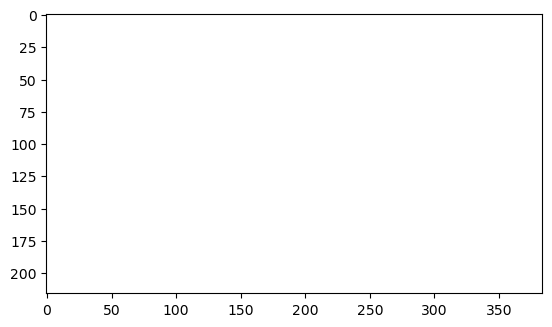

In [28]:
plt.imshow(np.imag(u_fft).reshape(xx.shape))

In [9]:
# number of nonuniform points
M = 100

# the nonuniform points
x = 2 * np.pi * np.random.uniform(size=M)
y = 2 * np.pi * np.random.uniform(size=M)

# their complex strengths
c = (np.random.standard_normal(size=M)
     + 1J * np.random.standard_normal(size=M))

# desired number of Fourier modes
N1, N2 = 50, 75

# calculate the type-1 NUFFT
f = finufft.nufft2d1(x, y, c, (N1, N2))

In [31]:
# number of nonuniform points
M = 100

# the nonuniform points
x = 2 * np.pi * np.random.uniform(size=M)
y = 2 * np.pi * np.random.uniform(size=M)

# their complex strengths
c = (np.random.standard_normal(size=M)
     + 1J * np.random.standard_normal(size=M))

In [32]:
x.shape

(100,)

In [33]:
y.shape

(100,)

In [34]:
c.shape

(100,)